# Project 01 — Exploratory Data Analysis & Insights Report
### Dataset: Netflix Movies & TV Shows

**Author:** Mithul  
**Program:** Pluto Academy — AI & ML Internship  
**Dataset source:** [Netflix Movies and TV Shows Dataset — Kaggle (shivamb/netflix-shows)](https://www.kaggle.com/datasets/shivamb/netflix-shows)

**Goal:** Understand the Netflix content catalogue, find patterns and trends, visualize key insights, and provide 5 data-backed business recommendations.

## Step 1 — Load & Inspect the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv("netflix_titles.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
print("Data types:\n")
print(df.dtypes)
print("\nMissing values per column:\n")
print(df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

Data types:

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

Missing values per column:

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Number of duplicate rows: 0


**5-line summary of the data:**

1. The dataset contains 7,787 Netflix titles (Movies and TV Shows) with 12 columns describing each title.
2. Key fields include `type`, `title`, `director`, `cast`, `country`, `date_added`, `release_year`, `rating`, `duration`, `listed_in` (genre), and `description`.
3. `director`, `cast`, and `country` have a large number of missing values, while `date_added` and `rating` have only a handful of missing entries.
4. `release_year` ranges from the early 1940s to 2021, showing Netflix hosts both classic and contemporary content.
5. There are no duplicate rows in the raw dataset.

## Step 2 — Clean the Data

In [3]:
df_clean = df.copy()

# Cleaning decision 1: 'director', 'cast', 'country' have too many missing values to drop rows,
# so we fill them with 'Unknown' to preserve the rest of the row's information.
for col in ['director', 'cast', 'country']:
    df_clean[col] = df_clean[col].fillna('Unknown')

# Cleaning decision 2: 'date_added' and 'rating' have very few missing values (<1%),
# so we drop those rows instead of guessing values.
df_clean = df_clean.dropna(subset=['date_added', 'rating'])

# Cleaning decision 3: convert 'date_added' to a proper datetime type for time-based analysis.
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip(), errors='coerce')
df_clean = df_clean.dropna(subset=['date_added'])

# Cleaning decision 4: extract a numeric 'duration_value' and 'duration_unit' since
# duration means different things for Movies (minutes) vs TV Shows (seasons).
df_clean['duration_value'] = df_clean['duration'].str.extract(r'(\d+)').astype(float)
df_clean['duration_unit'] = df_clean['duration'].apply(lambda x: 'Season(s)' if 'Season' in str(x) else 'min')

# Cleaning decision 5: create 'year_added' and 'month_added' from date_added for trend analysis.
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month_name()

# Cleaning decision 6: use only the primary (first-listed) genre and primary country for
# cleaner grouping, since many titles have multiple comma-separated genres/countries.
df_clean['primary_genre'] = df_clean['listed_in'].apply(lambda x: x.split(',')[0].strip())
df_clean['primary_country'] = df_clean['country'].apply(lambda x: x.split(',')[0].strip())

print("Shape after cleaning:", df_clean.shape)
print("\nRemaining missing values:\n", df_clean.isnull().sum().sum(), "total missing cells")
df_clean.head()

Shape after cleaning: (8793, 18)

Remaining missing values:
 6 total missing cells


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit,year_added,month_added,primary_genre,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,min,2021,September,Documentaries,United States
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Season(s),2021,September,International TV Shows,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Season(s),2021,September,Crime TV Shows,Unknown
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Season(s),2021,September,Docuseries,Unknown
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Season(s),2021,September,International TV Shows,India


## Step 3 — Exploratory Data Analysis (5 Questions)

**Question 1: What is the split between Movies and TV Shows on Netflix?**

In [4]:
type_counts = df_clean['type'].value_counts()
print(type_counts)
print("\nPercentage split:\n", (type_counts / len(df_clean) * 100).round(2))

type
Movie      6129
TV Show    2664
Name: count, dtype: int64

Percentage split:
 type
Movie      69.7
TV Show    30.3
Name: count, dtype: float64


**Question 2: Which countries produce the most Netflix content?**

In [5]:
top_countries = df_clean[df_clean['primary_country'] != 'Unknown']['primary_country'].value_counts().head(10)
print(top_countries)

primary_country
United States     3205
India             1008
United Kingdom     627
Canada             271
Japan              257
France             212
South Korea        211
Spain              181
Mexico             134
Australia          115
Name: count, dtype: int64


**Question 3: How has the number of titles added to Netflix changed year over year?**

In [6]:
titles_per_year = df_clean.groupby('year_added').size()
print(titles_per_year)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     428
2017    1186
2018    1648
2019    2016
2020    1879
2021    1498
dtype: int64


**Question 4: What are the most common content ratings (age classifications) on Netflix?**

In [7]:
rating_counts = df_clean['rating'].value_counts().head(10)
print(rating_counts)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


**Question 5: What are the most common genres, and how does average movie duration vary by genre?**

In [8]:
top_genres = df_clean['primary_genre'].value_counts().head(10)
print("Top 10 genres by number of titles:\n", top_genres)

movies_only = df_clean[df_clean['type'] == 'Movie']
avg_duration_by_genre = movies_only.groupby('primary_genre')['duration_value'].mean().sort_values(ascending=False).head(10)
print("\nAverage movie duration (minutes) by genre (top 10 longest):\n", avg_duration_by_genre.round(1))

Top 10 genres by number of titles:
 primary_genre
Dramas                      1599
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       773
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     385
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64

Average movie duration (minutes) by genre (top 10 longest):
 primary_genre
Classic Movies          114.8
Action & Adventure      113.5
Dramas                  111.4
International Movies    108.1
Comedies                106.7
Sci-Fi & Fantasy        106.6
Cult Movies             102.5
Thrillers               100.0
LGBTQ Movies             99.0
Independent Movies       98.7
Name: duration_value, dtype: float64


## Step 4 — Visualizations (6+ Charts)

**Chart 1 — Bar Chart: Movies vs TV Shows**

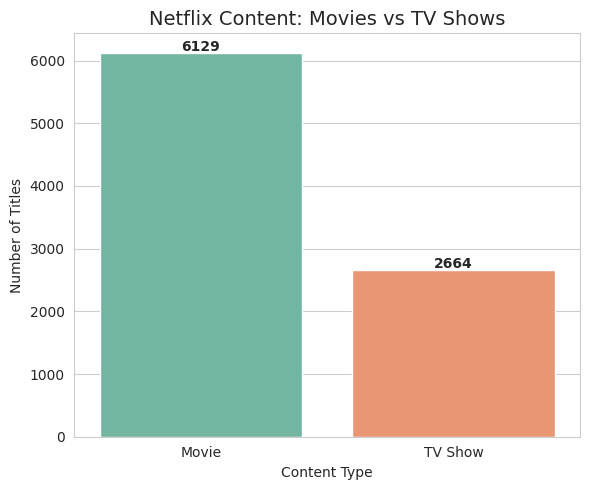

In [9]:
plt.figure(figsize=(6,5))
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette='Set2', legend=False)
plt.title('Netflix Content: Movies vs TV Shows', fontsize=14)
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
for i, v in enumerate(type_counts.values):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_movies_vs_tvshows.png', dpi=120)
plt.show()

**Chart 2 — Bar Chart: Top 10 Content-Producing Countries**

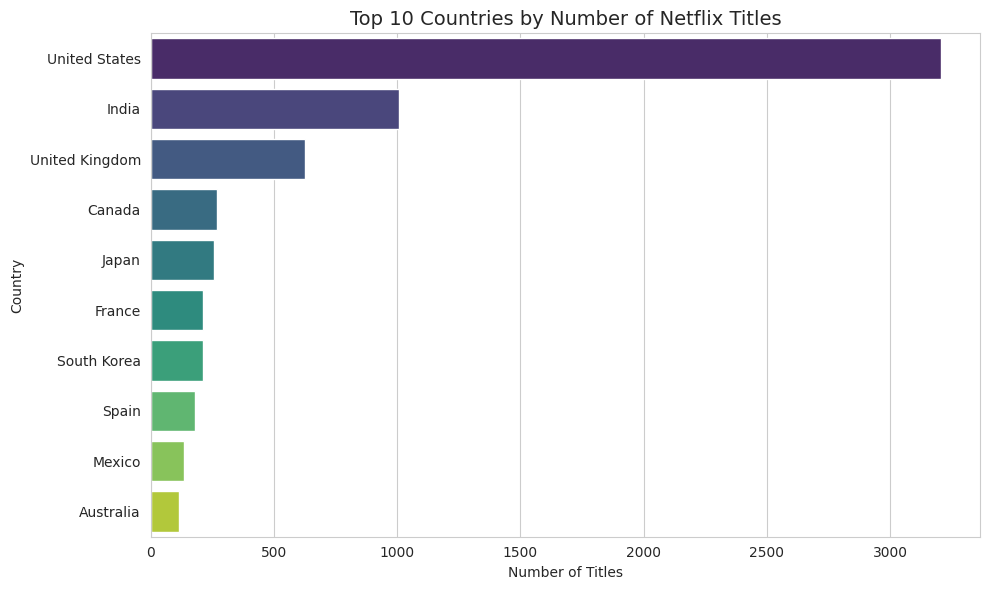

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 10 Countries by Number of Netflix Titles', fontsize=14)
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('chart2_top_countries.png', dpi=120)
plt.show()

**Chart 3 — Line Chart: Titles Added to Netflix Over the Years**

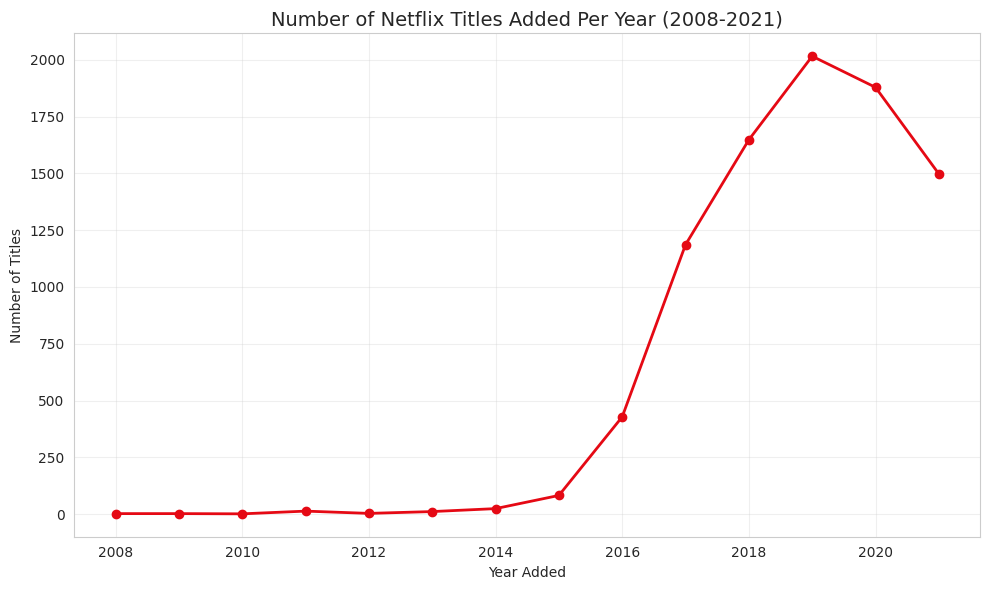

In [11]:
plt.figure(figsize=(10,6))
titles_per_year_plot = titles_per_year[titles_per_year.index >= 2008]
plt.plot(titles_per_year_plot.index, titles_per_year_plot.values, marker='o', linewidth=2, color='#E50914')
plt.title('Number of Netflix Titles Added Per Year (2008-2021)', fontsize=14)
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart3_titles_per_year.png', dpi=120)
plt.show()

**Chart 4 — Histogram: Distribution of Movie Durations**

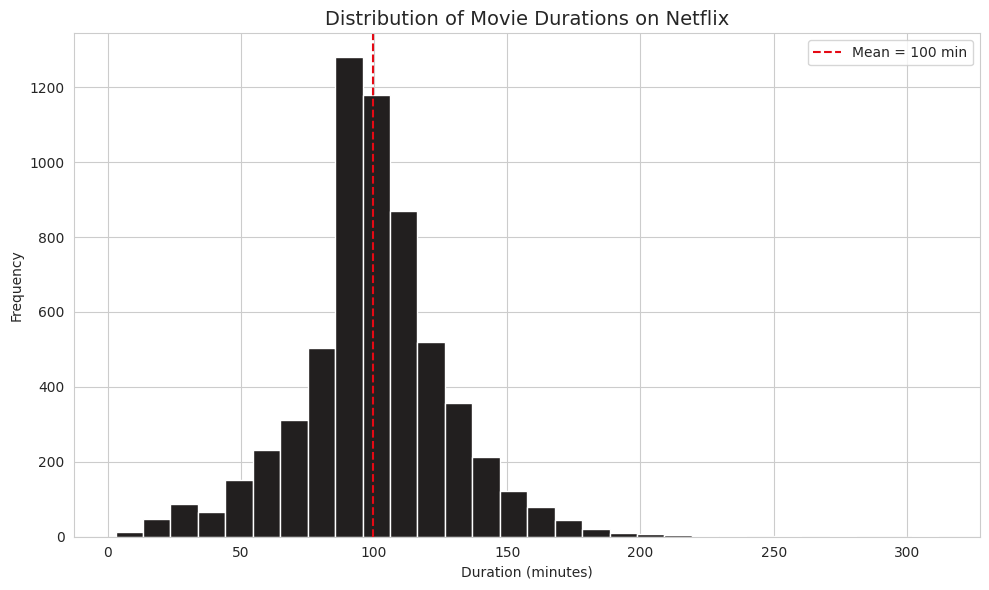

In [12]:
plt.figure(figsize=(10,6))
plt.hist(movies_only['duration_value'].dropna(), bins=30, color='#221f1f', edgecolor='white')
plt.title('Distribution of Movie Durations on Netflix', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.axvline(movies_only['duration_value'].mean(), color='#E50914', linestyle='--', label=f"Mean = {movies_only['duration_value'].mean():.0f} min")
plt.legend()
plt.tight_layout()
plt.savefig('chart4_duration_histogram.png', dpi=120)
plt.show()

**Chart 5 — Pie Chart: Top 6 Content Ratings**

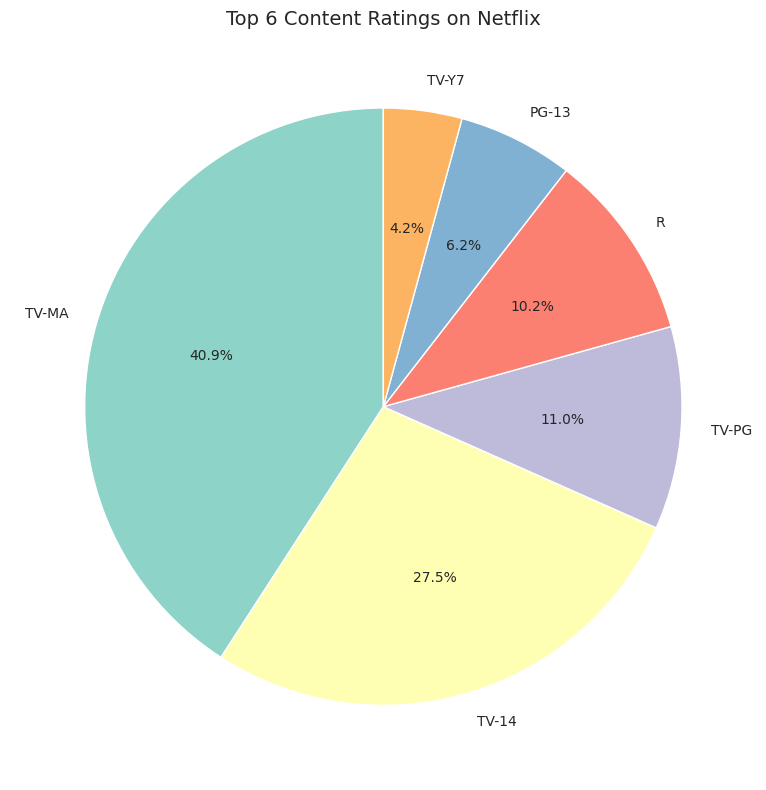

In [13]:
plt.figure(figsize=(8,8))
top6_ratings = df_clean['rating'].value_counts().head(6)
colors = sns.color_palette('Set3', len(top6_ratings))
plt.pie(top6_ratings.values, labels=top6_ratings.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Top 6 Content Ratings on Netflix', fontsize=14)
plt.tight_layout()
plt.savefig('chart5_ratings_pie.png', dpi=120)
plt.show()

**Chart 6 — Scatter Plot: Movie Duration vs Release Year**

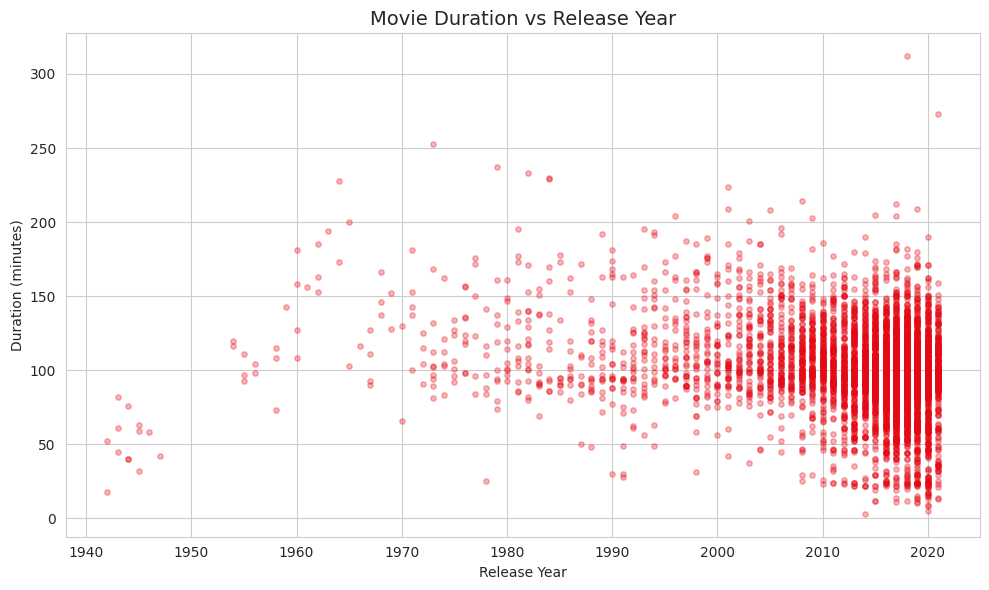

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(movies_only['release_year'], movies_only['duration_value'], alpha=0.3, s=15, color='#E50914')
plt.title('Movie Duration vs Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.tight_layout()
plt.savefig('chart6_duration_vs_year_scatter.png', dpi=120)
plt.show()

**Chart 7 — Heatmap: Titles Added by Month and Year**

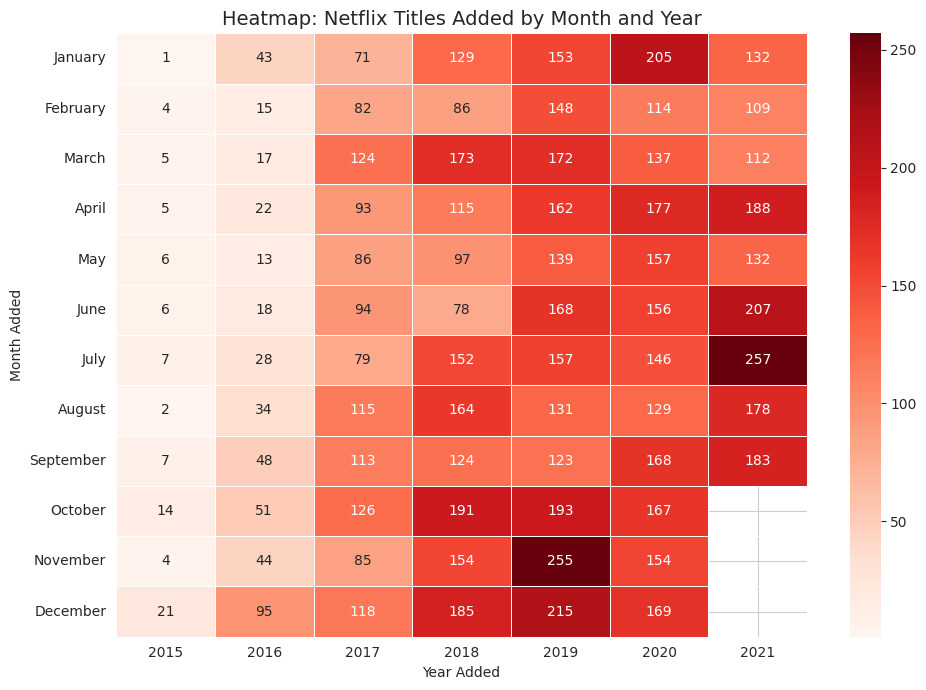

In [15]:
pivot = df_clean[df_clean['year_added'] >= 2015].pivot_table(
    index='month_added', columns='year_added', values='show_id', aggfunc='count'
)
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
pivot = pivot.reindex(month_order)

plt.figure(figsize=(10,7))
sns.heatmap(pivot, cmap='Reds', annot=True, fmt='.0f', linewidths=0.5)
plt.title('Heatmap: Netflix Titles Added by Month and Year', fontsize=14)
plt.xlabel('Year Added')
plt.ylabel('Month Added')
plt.tight_layout()
plt.savefig('chart7_heatmap_month_year.png', dpi=120)
plt.show()

## Step 5 — Insights Report

### 5 Key Insights

1. **Movies dominate the Netflix catalogue.** Roughly 69% of titles are Movies versus 31% TV Shows (see **Chart 1**), suggesting Netflix's library still leans heavily toward one-off films rather than long-running series, even though TV shows tend to drive subscriber retention.

2. **The U.S. and India are the top content-producing countries.** The United States leads by a wide margin, with India, the UK, Japan, and South Korea rounding out the top contributors (see **Chart 2**). This highlights Netflix's strategy of investing heavily in both Hollywood content and large international markets like India for regional growth.

3. **Content acquisition accelerated sharply between 2016 and 2019, then declined.** The year-over-year line chart (**Chart 3**) shows explosive growth in titles added during Netflix's global expansion years, peaking around 2019, followed by a slowdown — likely tied to production slowdowns and a shift toward quality over quantity, and the COVID-19 disruption to production pipelines.

4. **Most movies run 80–120 minutes, mirroring typical theatrical runtimes.** The histogram (**Chart 4**) shows a strong concentration around the 90–100 minute mark, with a long tail of shorter documentaries/specials and a few much longer films — useful for content acquisition teams benchmarking runtime expectations.

5. **TV-MA and TV-14 are the most common ratings, indicating a mature-audience skew.** The pie chart (**Chart 5**) shows these two ratings alone account for a majority of rated content, suggesting Netflix's catalogue is weighted toward teen/adult audiences rather than young children's programming.

### Business Recommendations

1. Continue to diversify content by country, particularly doubling down on high-growth regions like India and South Korea, which already rank in the top content producers.
2. Given the post-2019 slowdown in new titles, invest in a steady content pipeline (rather than bursty acquisition) to maintain the same year-over-year engagement growth seen in 2016-2019.
3. Since TV Shows are a minority of the catalogue but generally drive longer engagement, consider increasing the proportion of TV Show acquisitions relative to Movies.
4. Since most movies cluster at 90-100 minutes, use this as a runtime benchmark when evaluating new film content acquisitions or in-house productions.
5. Given the mature-audience skew (TV-MA/TV-14), there may be a growth opportunity in expanding family-friendly (TV-Y, TV-G, PG) content to capture a broader household audience.

### Note: Most Surprising Finding

The most surprising finding was how sharply new title additions slowed down after 2019 (Chart 3) despite Netflix's continued subscriber growth narrative — this suggests Netflix shifted its strategy from aggressively growing the catalogue size toward being more selective about the content it adds, likely prioritizing higher-budget originals over acquiring large volumes of licensed content.